# Task 3 — Model 2: LSTM (neural network)

One-step-ahead forecasts for the same three squares and **test week (16–22 Dec 2013)** as ARIMA. Each area has its **own** trained model. Training data: **Nov 1 – Dec 15, 2013** only.

In [1]:
# Core libraries
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Reproducibility and CPU device (no GPU required)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cpu")

In [3]:
# Paths and time windows (same as ARIMA notebook)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET_PATH = PROJECT_ROOT / "data" / "processed" / "milan_internet_traffic.parquet"
FOCUS_PATH = PROJECT_ROOT / "data" / "processed" / "task2_focus_squares.csv"
FIG_DIR = PROJECT_ROOT / "figures" / "task3_lstm"
OUT_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_START, TRAIN_END = "2013-11-01", "2013-12-16"
TEST_START, TEST_END = "2013-12-16", "2013-12-23"

In [4]:
# Hyperparameters (tuned from Task 2 daily period = 144 ten-minute steps)
SEQ_LEN = 144          # input history length (1 day)
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.1
EPOCHS = 25
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
VAL_FRACTION = 0.1   # last 10% of training windows for validation

In [5]:
# Focus squares from Task 2
focus = pd.read_csv(FOCUS_PATH)
SQUARE_IDS = focus["square_id"].tolist()
LABELS = dict(zip(focus["square_id"], focus["label"]))
print(focus)

         label  square_id
0      highest       5161
1  square_4159       4159
2  square_4556       4556


## Model description (for report)

**LSTM** maps a sequence of past traffic values to the next value:
- **Input:** vector of length `SEQ_LEN` = 144 (10-minute slots ≈ one day), one channel.
- **Preprocessing:** `MinMaxScaler` fit on **training** traffic only; inverse-transform for plots/metrics.
- **Architecture:** 2-layer LSTM (hidden 64) → linear head → one-step output.
- **Training:** sliding windows on Nov–Dec 15; Adam + MSE; early stopping on validation loss.
- **Test:** one-step-ahead with **true** history (each step uses actual traffic up to \(t\)).

In [6]:
# Load three squares once
traffic = pd.read_parquet(PARQUET_PATH)
traffic = traffic[traffic["square_id"].isin(SQUARE_IDS)]
print(f"Subset rows: {len(traffic):,}")

Subset rows: 26,784


In [7]:
def series_for_square(square_id: int, t0: str, t1: str) -> pd.Series:
    """Regular 10-minute series for one square in [t0, t1)."""
    chunk = traffic[(traffic["square_id"] == square_id) & (traffic["time"] >= t0) & (traffic["time"] < t1)]
    s = chunk.set_index("time")["internet"].sort_index()
    idx = pd.date_range(t0, t1, freq="10min", inclusive="left")
    return s.reindex(idx, fill_value=0).astype(float)

In [8]:
def make_supervised_windows(series_1d: np.ndarray, seq_len: int):
    """Build (X, y) pairs: X = past seq_len values, y = next value."""
    X, y = [], []
    for i in range(len(series_1d) - seq_len):
        X.append(series_1d[i : i + seq_len])
        y.append(series_1d[i + seq_len])
    X = np.array(X, dtype=np.float32)[:, :, None]  # (n, seq_len, 1)
    y = np.array(y, dtype=np.float32)[:, None]
    return X, y

In [9]:
class LSTMForecaster(nn.Module):
    """Stacked LSTM + linear layer for one-step prediction."""

    def __init__(self, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)

In [10]:
def prepare_training_data(train_series: pd.Series):
    """Scale train series and build train/validation loaders."""
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(train_series.values.reshape(-1, 1)).flatten()
    X, y = make_supervised_windows(scaled, SEQ_LEN)
    n_val = max(1, int(len(X) * VAL_FRACTION))
    loader = DataLoader(
        TensorDataset(torch.tensor(X[:-n_val]), torch.tensor(y[:-n_val])),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    val_X, val_y = torch.tensor(X[-n_val:]), torch.tensor(y[-n_val:])
    return scaler, loader, val_X, val_y

In [11]:
def fit_lstm_model(train_loader, val_X, val_y):
    """Train with Adam; early stopping on validation MSE."""
    model = LSTMForecaster(HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    best_val, best_state, bad = np.inf, None, 0
    t0 = time.perf_counter()
    for _ in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE)).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            vloss = loss_fn(model(val_X.to(DEVICE)), val_y.to(DEVICE)).item()
        if vloss < best_val:
            best_val, best_state, bad = vloss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= 5:
                break
    model.load_state_dict(best_state)
    return model, time.perf_counter() - t0

In [12]:
def train_lstm(train_series: pd.Series):
    """Full training pipeline for one square."""
    scaler, loader, val_X, val_y = prepare_training_data(train_series)
    model, train_sec = fit_lstm_model(loader, val_X, val_y)
    return model, scaler, train_sec

In [13]:
def forecast_test_week(model, scaler, train: pd.Series, test: pd.Series) -> pd.Series:
    """One-step-ahead preds using true history (train + actual test values)."""
    model.eval()
    history = train.values.astype(float).tolist()
    preds = []
    t0 = time.perf_counter()
    for actual in test.values:
        window = np.array(history[-SEQ_LEN:], dtype=np.float32).reshape(-1, 1)
        w_scaled = scaler.transform(window).flatten()
        x = torch.tensor(w_scaled.reshape(1, SEQ_LEN, 1)).to(DEVICE)
        with torch.no_grad():
            p_scaled = model(x).cpu().numpy().ravel()[0]
        p = scaler.inverse_transform([[p_scaled]])[0, 0]
        preds.append(float(p))
        history.append(float(actual))
    return pd.Series(preds, index=test.index, name="predicted"), time.perf_counter() - t0

In [14]:
def error_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """MAE, MAPE (%), RMSE (same definitions as ARIMA notebook)."""
    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    denom = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs(err / denom)) * 100
    rmse = np.sqrt(np.mean(err ** 2))
    return {"MAE": mae, "MAPE": mape, "RMSE": rmse}

## Train and evaluate — each square independently

In [15]:
results = {}
metrics = []
timings = []

for sq in SQUARE_IDS:
    train = series_for_square(sq, TRAIN_START, TRAIN_END)
    test = series_for_square(sq, TEST_START, TEST_END)

    model, scaler, train_sec = train_lstm(train)
    pred, forecast_sec = forecast_test_week(model, scaler, train, test)

    m = error_metrics(test.values, pred.values)
    m.update({"square_id": sq, "label": LABELS[sq], "model": "LSTM"})
    metrics.append(m)
    timings.append({"square_id": sq, "train_sec": train_sec, "forecast_sec": forecast_sec})
    results[sq] = pd.DataFrame({"actual": test, "predicted": pred})
    print(f"Square {sq}: train {train_sec:.1f}s, forecast {forecast_sec:.1f}s, MAE={m['MAE']:.2f}")

Square 5161: train 1147.1s, forecast 9.7s, MAE=102.65
Square 4159: train 336.5s, forecast 4.2s, MAE=15.20
Square 4556: train 268.6s, forecast 3.8s, MAE=27.14


In [16]:
metrics_df = pd.DataFrame(metrics)[["label", "square_id", "model", "MAE", "MAPE", "RMSE"]]
display(metrics_df)
metrics_df.to_csv(OUT_DIR / "lstm_metrics_by_area.csv", index=False)

,label,square_id,model,MAE,MAPE,RMSE
0,highest,5161,LSTM,102.647756,13.716416,144.988367
1,square_4159,4159,LSTM,15.199421,7.170866,20.160995
2,square_4556,4556,LSTM,27.142129,6.371909,36.025386


In [17]:
timing_df = pd.DataFrame(timings)
timing_df["hardware"] = platform.platform()
timing_df["python"] = platform.python_version()
timing_df["seq_len"] = SEQ_LEN
display(timing_df)
timing_df.to_csv(OUT_DIR / "lstm_timings.csv", index=False)

,square_id,train_sec,forecast_sec,hardware,python,seq_len
0,5161,1147.129538,9.736985,Windows-11-10.0.26100-SP0,3.14.0,144
1,4159,336.532970,4.163350,Windows-11-10.0.26100-SP0,3.14.0,144
2,4556,268.608473,3.834859,Windows-11-10.0.26100-SP0,3.14.0,144


## Plots — actual vs LSTM prediction (test week)

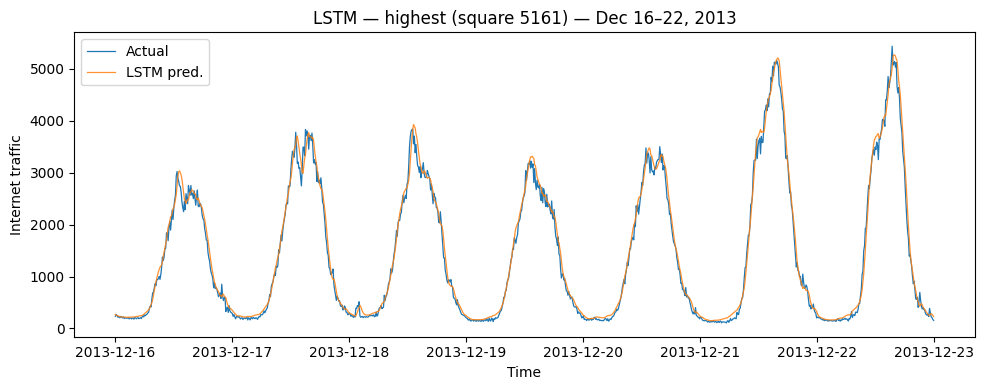

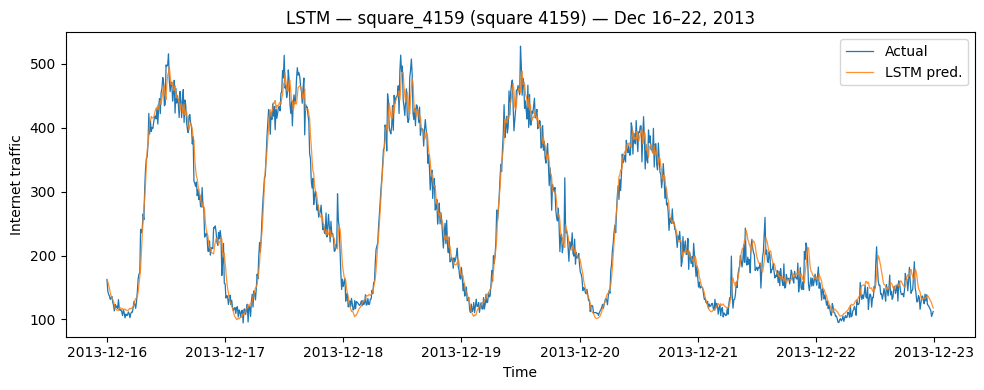

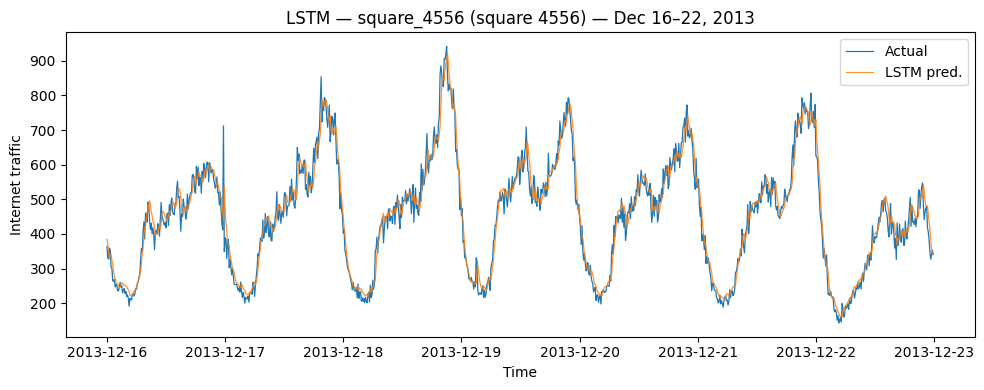

In [18]:
for sq in SQUARE_IDS:
    df = results[sq]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df.index, df["actual"], label="Actual", linewidth=0.9)
    ax.plot(df.index, df["predicted"], label="LSTM pred.", linewidth=0.9, alpha=0.85)
    ax.set_title(f"LSTM — {LABELS[sq]} (square {sq}) — Dec 16–22, 2013")
    ax.set_xlabel("Time")
    ax.set_ylabel("Internet traffic")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"lstm_square_{sq}.png", dpi=150)
    plt.show()

In [19]:
# Save predictions for comparison with ARIMA and the third model
for sq, df in results.items():
    path = OUT_DIR / f"lstm_predictions_square_{sq}.csv"
    df.to_csv(path)
    print(f"Saved {path.name}")

Saved lstm_predictions_square_5161.csv
Saved lstm_predictions_square_4159.csv
Saved lstm_predictions_square_4556.csv


## Experimentation notes (for report)

| Parameter | Value | Reason |
|-----------|-------|--------|
| `SEQ_LEN` | 144 | Task 2 daily seasonality (144 × 10 min) |
| `HIDDEN_SIZE` | 64 | Balance capacity vs overfitting on ~6k train steps |
| `EPOCHS` / early stop | 25 / patience 5 | Stop when validation MSE plateaus |
| `MinMaxScaler` | train only | Prevents leakage from test week |

**Compare** `lstm_metrics_by_area.csv` with `arima_metrics_by_area.csv` in the final Task 3 discussion.